# Sun Probability Framework - SPF & General Health

**Data**:

- [Sun Probability Framework 2025](https://data.imago.ac.uk/datasets/cloud-probability-statistics-per-small-area-in-2025-version-2-0)
- [Census 2021 General Health, LSOA level](https://www.nomisweb.co.uk/default.asp)

**Goal**: Investigate how Sun Probability Framework (SPF) values vary across communities with different levels of self reported general health in England.

## Installing the data

Download the 2025 SPF dataset from the Imago Data Service.

Download the Census 2021 General Health data at LSOA level. Select all columns, LSOA, values, and area codes.

Place both files inside the `/data` directory. Rename the census csv to `generalhealth.csv`. 

The SPF dataset provides annual estimates of the Sunlight Probability Factor for each LSOA. The Census dataset provides counts of residents reporting different levels of general health in the 2021 Census.

# Why?

Environmental conditions are not necessarily experienced equally across society.

Researchers are often interested in whether environmental characteristics vary systematically with characteristics of the populations living in different areas. Comparing SPF with Census measures of general health allows us to investigate whether communities with different levels of self reported health tend to experience different sunlight conditions.

This analysis does not attempt to establish that sunlight conditions cause differences in health. Instead, it investigates whether a spatial association exists between the two variables and considers possible explanations and limitations.

The Census measure of general health is based on how residents assessed their own health, ranging from very good to very bad.

## Installing Libraries

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from scipy.stats import pearsonr

## Loading the datasets

In [42]:
spf = gpd.read_file("../data/SPF_LSOA_level_2025.gpkg")

health = pd.read_csv(
    "../data/generalhealth.csv", skiprows=6, skipfooter=6, engine="python"
)

### Understanding the datasets


In [43]:
display(spf.head())

display(health.head())

,data_zone_code,cloudprob_corrected_mean,valid_count_mean,geometry
0,E01000001,65.818301,406.0,"MULTIPOLYGON (((532105.312 182010.574, 532162...."
1,E01000002,65.014500,406.0,"MULTIPOLYGON (((532634.497 181926.016, 532619...."
2,E01000003,67.964887,406.0,"MULTIPOLYGON (((532135.138 182198.131, 532158...."
3,E01000005,64.926294,406.0,"MULTIPOLYGON (((533808.018 180767.774, 533649...."
4,E01000006,65.903553,203.0,"MULTIPOLYGON (((545122.049 184314.931, 545271...."


,2021 super output area - lower layer,mnemonic,Total: All usual residents,Very good health,Good health,Fair health,Bad health,Very bad health
0,Hartlepool 001A,E01011954,2283,970,767,381,130,35
1,Hartlepool 001B,E01011969,1345,574,460,228,60,23
2,Hartlepool 001C,E01011970,1070,485,393,142,38,12
3,Hartlepool 001D,E01011971,1323,743,410,136,27,7
4,Hartlepool 001F,E01033465,1955,1098,613,181,48,15


The SPF dataset contains annual average SPF values for every LSOA.

The Census health categories are:

- Very good health  
- Good health  
- Fair health  
- Bad health  
- Very bad health  

The Census data provides counts rather than percentages. This allows us to calculate the proportions ourselves.

### Preparing Census Data 

In [44]:
health = health.rename(
    columns={
        "2021 super output area - lower layer": "lsoa_name",
        "mnemonic": "data_zone_code",
        "Total: All usual residents": "total",
        "Very good health": "very_good",
        "Good health": "good",
        "Fair health": "fair",
        "Bad health": "bad",
        "Very bad health": "very_bad",
    }
)
health.columns

Index(['lsoa_name', 'data_zone_code', 'total', 'very_good', 'good', 'fair',
       'bad', 'very_bad'],
      dtype='str')

## Creating health measures

Counts are difficult to compare directly because LSOAs contain different numbers of people. Instead, we convert the counts into percentages.

### Good health

In [45]:
health["good_health_percent"] = (
    100 * (health["very_good"] + health["good"]) / health["total"]
)

### Poor health

We will use the inverse of Good health so bad + very bad health as our principal measure.

In [46]:
health["poor_health_percent"] = (
    100 * (health["bad"] + health["very_bad"]) / health["total"]
)

### Fair health

Finally we calculate the percentage of fair health.

In [47]:
health["fair_health_percent"] = 100 * health["fair"] / health["total"]

We can inspect the resulting variables:

In [48]:
display(
    health[
        [
            "data_zone_code",
            "good_health_percent",
            "fair_health_percent",
            "poor_health_percent",
        ]
    ].head()
)

,data_zone_code,good_health_percent,fair_health_percent,poor_health_percent
0,E01011954,76.084100,16.688568,7.227332
1,E01011969,76.877323,16.951673,6.171004
2,E01011970,82.056075,13.271028,4.672897
3,E01011971,87.150416,10.279667,2.569917
4,E01033465,87.519182,9.258312,3.222506


We should check the first couple to ensure that they sum to 100%, as small differences would suggest missing data or rounding errors.

In [49]:
health[
    [
        "good_health_percent",
        "fair_health_percent",
        "poor_health_percent",
    ]
].sum(
    axis=1
).head(10)

0    100.0
1    100.0
2    100.0
3    100.0
4    100.0
5    100.0
6    100.0
7    100.0
8    100.0
9    100.0
dtype: float64

## Merging the datasets

The SPF dataset uses the 2021 LSOA code as data_zone_code.

We therefore merge the health data using the same identifier.

In [50]:
health = health[
    [
        "data_zone_code",
        "good_health_percent",
        "fair_health_percent",
        "poor_health_percent",
    ]
]

combined = spf.merge(
    health,
    on="data_zone_code",
    how="inner",
)

print(f"SPF LSOAs: {len(combined)}")
combined.head()

SPF LSOAs: 35672


,data_zone_code,cloudprob_corrected_mean,valid_count_mean,geometry,good_health_percent,fair_health_percent,poor_health_percent
0,E01000001,65.818301,406.0,"MULTIPOLYGON (((532105.312 182010.574, 532162....",89.966102,8.067797,1.966102
1,E01000002,65.014500,406.0,"MULTIPOLYGON (((532634.497 181926.016, 532619....",90.968208,6.719653,2.312139
2,E01000003,67.964887,406.0,"MULTIPOLYGON (((532135.138 182198.131, 532158....",85.368878,11.469312,3.161810
3,E01000005,64.926294,406.0,"MULTIPOLYGON (((533808.018 180767.774, 533649....",80.818182,12.000000,7.181818
4,E01000006,65.903553,203.0,"MULTIPOLYGON (((545122.049 184314.931, 545271....",84.407147,12.181917,3.410937


## Maps of the Data

Before investigating relationships between the variables, it is useful to visualise them independently.

This allows us to understand their spatial distributions before comparing them.

### SPF Map

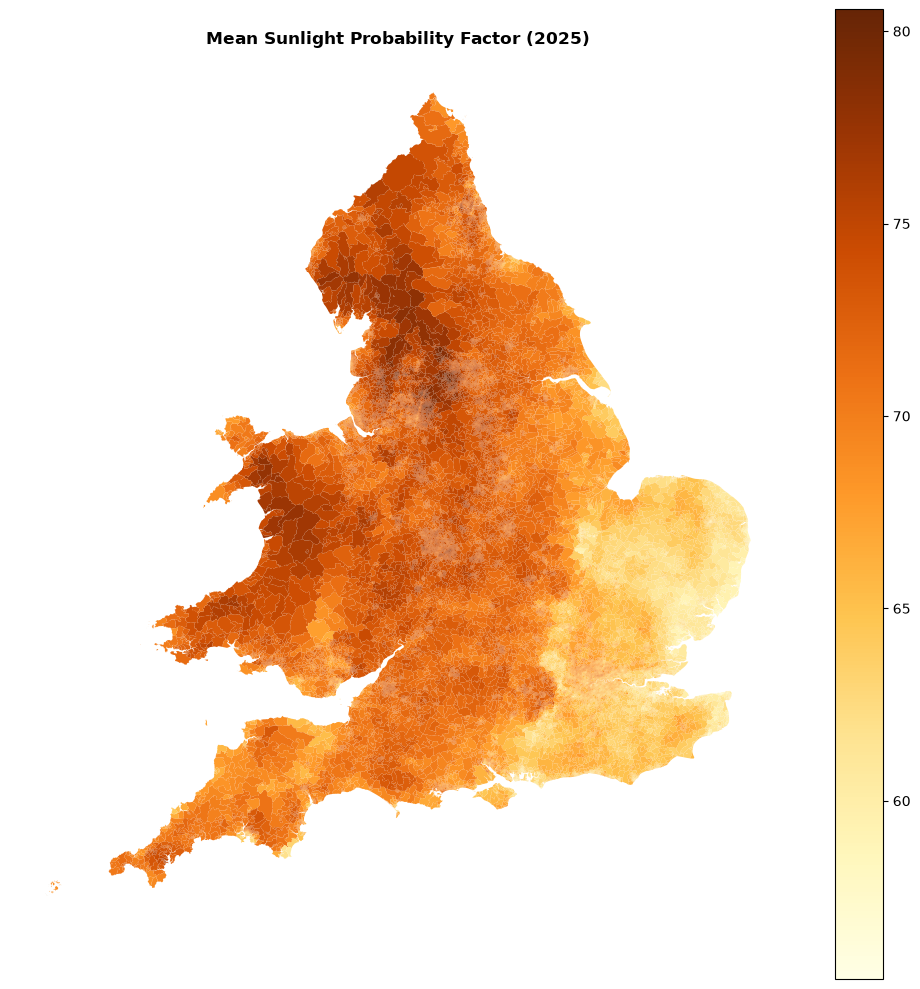

In [51]:
fig, ax = plt.subplots(figsize=(10, 10))

combined.plot(
    column="cloudprob_corrected_mean",
    cmap="YlOrBr",
    legend=True,
    ax=ax,
)

ax.axis("off")

ax.set_title(
    "Mean Sunlight Probability Factor (2025)",
    fontweight="bold",
)

plt.tight_layout()
plt.show()

**Interpretation**

The SPF map shows substantial spatial variation across England and Wales.

Remember that SPF represents the probability of cloud cover rather than the amount of sunlight itself. This means that:

- Higher SPF = greater probability of cloud cover  
- Lower SPF = lower probability of cloud cover  

Consequently, areas with lower SPF values represent areas where clearer conditions are more likely.

The map provides the environmental context for the remainder of the analysis.

### General Health Map

We now map the proportion of residents reporting bad or very bad general health.

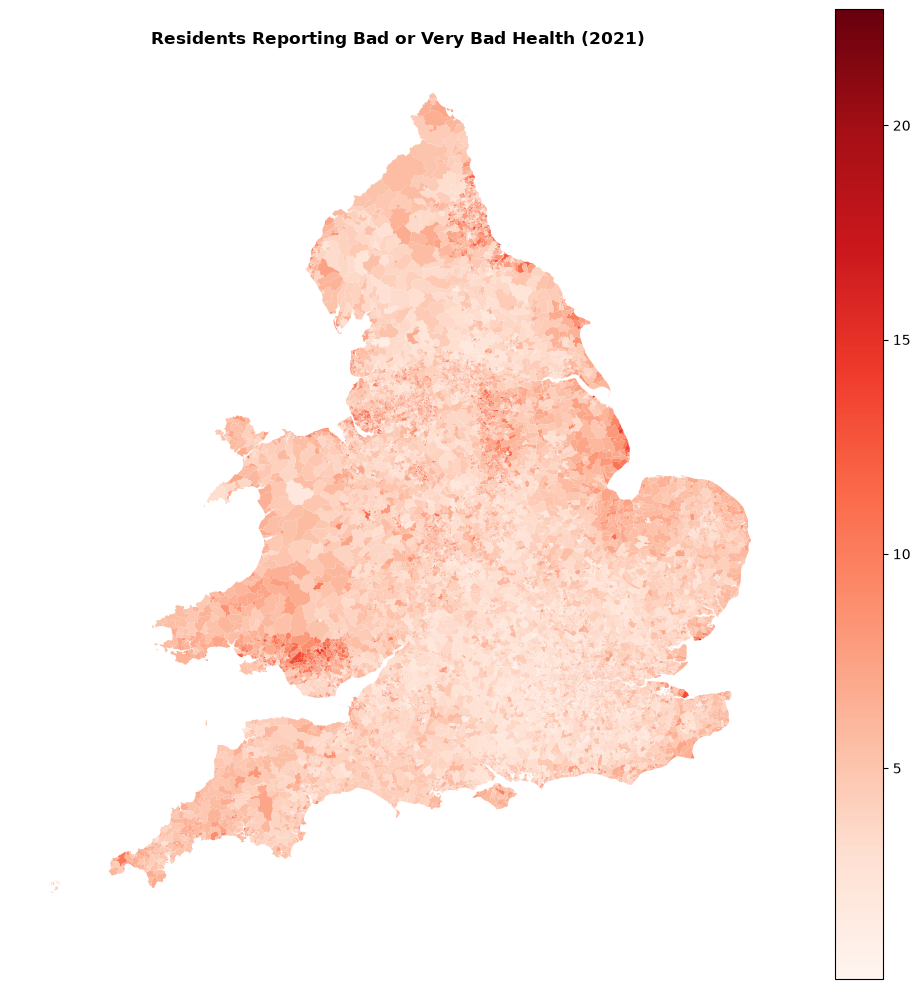

In [52]:
fig, ax = plt.subplots(figsize=(10, 10))

combined.plot(
    column="poor_health_percent",
    cmap="Reds",
    legend=True,
    ax=ax,
)

ax.axis("off")

ax.set_title(
    "Residents Reporting Bad or Very Bad Health (2021)",
    fontweight="bold",
)

plt.tight_layout()
plt.show()

**Interpretation**

The map shows significant geographical variation in self reported poor health. Higher values indicate LSOAs where a greater proportion of residents reported their general health as bad or very bad.

Despite this, the two maps should be considered independently. Similar looking spatial patterns, or a lack of spatial patterns, do not by themselves demonstrate a relationship or lack of one between SPF and health.

## Comparing SPF Across Health Groups

To investigate whether SPF varies systematically with health, we divide LSOAs into five groups according to their level of poor self reported health.

Quintiles divide the LSOAs into five approximately equal sized groups.

In [53]:
combined["health_quintile"] = pd.qcut(
    combined["poor_health_percent"],
    q=5,
    labels=[
        "Lowest poor health",
        "Low",
        "Medium",
        "High",
        "Highest poor health",
    ],
)

We can calculate the mean and median SPF within each group.

In [54]:
health_summary = combined.groupby("health_quintile", observed=False).agg(
    Mean_SPF=("cloudprob_corrected_mean", "mean"),
    Median_SPF=("cloudprob_corrected_mean", "median"),
    Count=("cloudprob_corrected_mean", "count"),
)

health_summary

,Mean_SPF,Median_SPF,Count
health_quintile,,,
Lowest poor health,68.770851,68.420633,7135
Low,69.104788,69.483485,7134
Medium,69.470494,70.164028,7134
High,70.002499,71.068138,7134
Highest poor health,70.833660,71.652135,7135


This comparison allows us to ask a simple question:

- *Do LSOAs with different levels of poor self reported health tend to have different SPF values?*

With the mean SPF increasing marginally between the groups, with a total of **2** SPF difference between the least poor health and highest poor health, this suggests that areas with greater levels of reported poor health tend to experience higher probabilities of cloud cover.

However, a difference between groups does not tell us why the difference exists.

## Correlation

The grouped comparison gives us a broad picture, but it discards some information by putting continuous health values into five groups.

We can therefore examine the relationship directly using a correlation.

In [55]:
correlation, p_value = pearsonr(
    combined["poor_health_percent"],
    combined["cloudprob_corrected_mean"],
)

print(f"Pearson correlation: {correlation:.3f}")
print(f"P-value: {p_value:.3e}")

Pearson correlation: 0.164
P-value: 6.773e-214


The Pearson correlation measures the strength and direction of the linear relationship between the percentage reporting bad or very bad health and SPF.

The positive value of **0.164** suggests that yes, there is a correlation, however it is very weak and making up a rather small portion of the overall change. The p-value being so near zero means that this is guaranteed statistically significant.

However, because the analysis contains thousands of LSOAs, even relatively small correlations can produce extremely small p-values. Statistical significance therefore does not necessarily mean that the relationship is substantively large or important.

## Scatterplot

A scatterplot allows us to see the relationship directly, making it potentially more clear if this pattern is even visible.

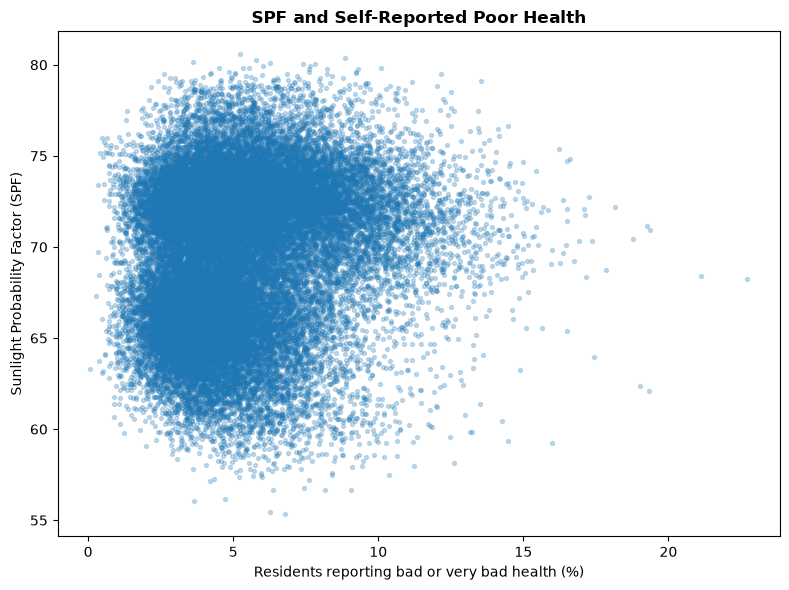

In [56]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(
    combined["poor_health_percent"],
    combined["cloudprob_corrected_mean"],
    alpha=0.25,
    s=8,
)

ax.set_xlabel("Residents reporting bad or very bad health (%)")

ax.set_ylabel("Sunlight Probability Factor (SPF)")

ax.set_title(
    "SPF and Self-Reported Poor Health",
    fontweight="bold",
)

plt.tight_layout()
plt.show()

The scatter plot also shows a positive relationship between the proportion of residents reporting bad or very bad health and SPF. LSOAs with higher levels of self reported poor health tend to have higher SPF values, although the relationship is relatively weak visually and there is substantial variation between individual areas.

## Exploring Fair Health

The previous analysis focused on residents reporting bad or very bad health. However, this represents only the most severe end of the Census health categories.

It is possible that a relationship with environmental conditions would appear earlier in the health distribution, for example through a shift from good or very good health towards fair health.

Rather than analysing every Census category separately, we therefore use the proportion of residents reporting **fair health** as a secondary measure.

This provides a useful check of whether the relationship observed for poor health is also present further up the health distribution.

In [58]:
fair_correlation, fair_p_value = pearsonr(
    combined["fair_health_percent"],
    combined["cloudprob_corrected_mean"],
)

print(f"Pearson correlation: {fair_correlation:.3f}")
print(f"P-value: {fair_p_value:.3e}")

Pearson correlation: 0.151
P-value: 5.915e-182


The correlation between the proportion reporting fair health and SPF is **0.151**, compared with **0.164** for bad or very bad health.

This provides a useful comparison with the previous result. The correlation is also positive, suggesting a weak correlation that is weaker than the correlation between poor health and fair health.

However, the strength of the relationship remains important. As with the poor-health analysis, a statistically significant correlation does not necessarily indicate a large or substantively important relationship.

### Scatterplot

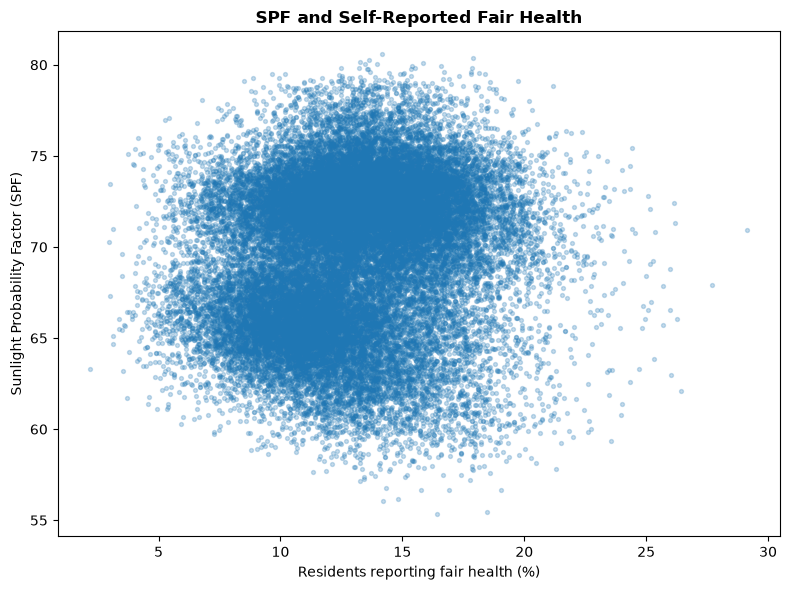

In [60]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(
    combined["fair_health_percent"],
    combined["cloudprob_corrected_mean"],
    alpha=0.25,
    s=8,
)

ax.set_xlabel("Residents reporting fair health (%)")
ax.set_ylabel("Sunlight Probability Factor (SPF)")

ax.set_title(
    "SPF and Self-Reported Fair Health",
    fontweight="bold",
)

plt.tight_layout()
plt.show()

The scatterplot provides a visual check of the correlation. As with poor health, there is substantial variation in SPF between individual LSOAs, meaning that health alone does not explain the environmental variation between communities.

## Exploring the Spatial Pattern

The statistical analysis suggests a weak positive relationship between SPF and self reported poor health. However, a correlation does not tell us whether this relationship is spatially concentrated or whether it is distributed relatively evenly across England.

To explore this, we identify LSOAs that are in the highest quintile for both SPF and the proportion of residents reporting fair or poor health.

This does not mean that these areas have worse health because of cloudier conditions. Instead, it highlights areas where the two characteristics occur together and allows us to consider whether any clear spatial pattern is visible.

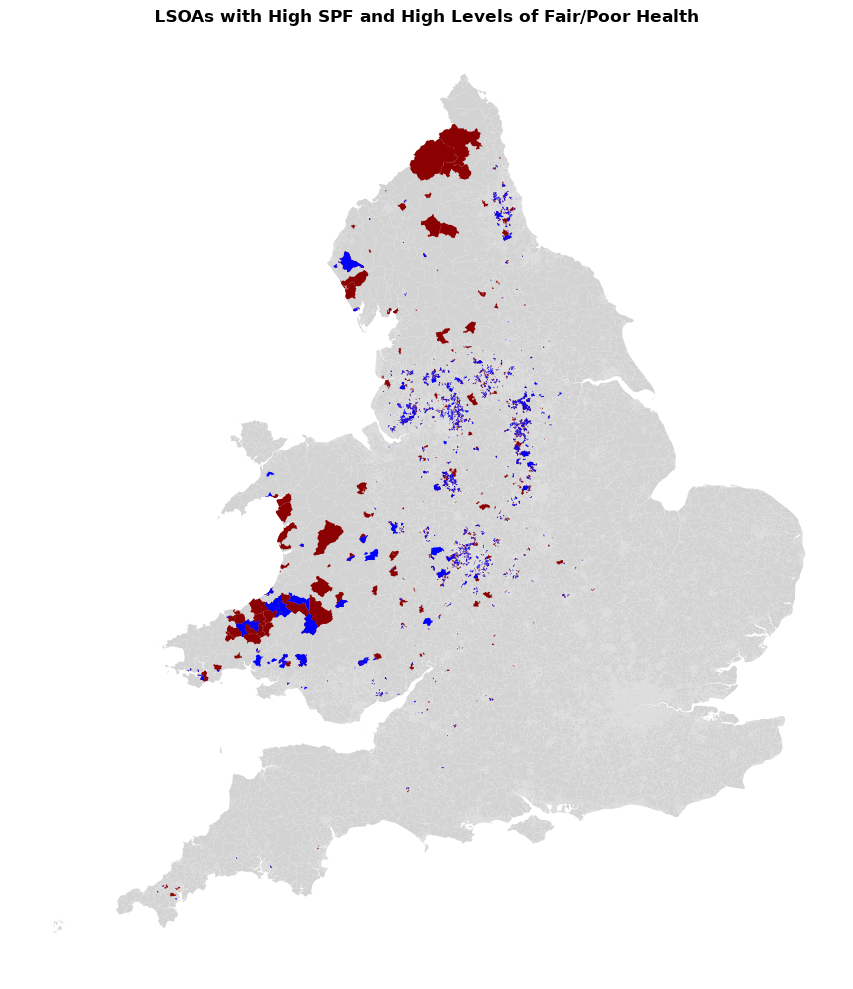

In [ ]:
# Create quintiles for SPF, fair health and poor health

combined["spf_quintile"] = pd.qcut(
    combined["cloudprob_corrected_mean"],
    q=5,
    labels=False,
)

combined["fair_health_quintile"] = pd.qcut(
    combined["fair_health_percent"],
    q=5,
    labels=False,
)

combined["poor_health_quintile"] = pd.qcut(
    combined["poor_health_percent"],
    q=5,
    labels=False,
)

# Identify areas in the highest quintile for each combination

combined["high_spf_high_fair"] = (combined["spf_quintile"] == 4) & (
    combined["fair_health_quintile"] == 4
)

combined["high_spf_high_poor"] = (combined["spf_quintile"] == 4) & (
    combined["poor_health_quintile"] == 4
)

fig, ax = plt.subplots(figsize=(10, 10))

combined.plot(
    color="lightgrey",
    ax=ax,
)

combined[combined["high_spf_high_fair"]].plot(
    color="darkred",
    ax=ax,
)

combined[combined["high_spf_high_poor"]].plot(
    color="blue",
    ax=ax,
)

ax.axis("off")

ax.set_title(
    "LSOAs with High SPF and High Levels of Fair/Poor Health",
    fontweight="bold",
)

plt.tight_layout()
plt.show()

Among LSOAs in the highest SPF quintile, there is a clear spatial difference between areas with high levels of fair health and those with high levels of poor or very poor health. The LSOAs seem to overlap quite heavily stretching from Wales up to North England, lining up quite heavily with the idea of the weather being worse in the north west of the country. 

# What Have We Learnt?

In this notebook we have:

- combined the 2025 Sunlight Probability Factor with Census 2021 general health data  
- examined the spatial distribution of SPF across England  
- examined the spatial distribution of self reported poor health  
- calculated the proportion of residents reporting bad or very bad health for each LSOA  
- compared SPF across groups with different levels of poor health  
- calculated the correlation between SPF and poor/fair health  
- visualised the relationships using a scatterplot  
- identified areas where high SPF and high levels of poor/fair health occur together  

The analysis suggests that there is an association between SPF and self reported general health, but the relationship should not be interpreted as evidence that cloud cover or sunlight conditions directly affect population health.

The analysis is conducted at the LSOA level, meaning that it describes spatial patterns between communities rather than relationships between individuals. This is particularly important when interpreting health data, as an association between areas does not imply that individuals experiencing poorer health necessarily experience different sunlight conditions.